# Fitting the GPLVM to bilateral spike counts stored in cell metrics
Sidney Rafilson | Buzsaki Lab

Animal: R02

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import os
import pandas as pd
from scipy.stats import zscore
from scipy.signal import sosfiltfilt, butter
from scipy.ndimage import gaussian_filter1d
import jax.numpy as jnp
import jax.random as jr
import poor_man_gplvm as pmg

from core import *

%matplotlib widget

c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\h5py\__init__.py:36: UserWarning:

h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems



## User configuration
All config for the analysis will be specified in this cell

In [2]:
# ----------------------------- Config ---------------------------------

# Data paths and session info
BASEPATH = r"Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106"
FIG_DIR = os.path.join(BASEPATH, "figures")
ANALYSIS_DIR = os.path.join(BASEPATH, "gplvm_results")

# probes, brain regions, and cell types
PROBES = [0, 1, 2, 3]                   # Probes to include in the analysis. There should be a corresponding basePath/baseName_imec{probe}.session.mat for each probe number
BRAIN_REGIONS = ['CA1']                 # Brain regions to include in the analysis (these are stored as tags in Cell Metrics, e.g., 'CA1', 'CA3', 'DG')
NEURON_TYPES = ['Pyramidal Cell']       # Neuron types to include in the analysis
EXCLUSION_TAGS = ['Bad']                # Tags for excluding neurons (e.g., 'Bad', 'Noise')


# Params for binning spike counts
WINDOW_SIZE = 0.01                      # s
STEP_SIZE   = 0.01                      # s
REFRACTORY_PERIOD_VIOLATIONS = 2        # percentage of allowed ISI less than 2ms

# Params for population burst detection
BURST_THRESHOLD = 3                 # z-scored population firing rate threshold for burst detection
BURST_BOUNDARY_THRESHOLD = 0        # z-scored population firing rate threshold for defining burst boundaries (start and end)
MIN_BURST_DURATION = 0.05           # minimum burst duration in seconds
MIN_INTERBURST_INTERVAL = 0.2      # minimum interval between bursts in seconds (will merge bursts that are closer than this)

# Params for the GPLVM
N_LATENT_BINS = 100
MOVEMENT_VARIANCE = 1
TUNING_LENGTHSCALE = 10


# Filtering thresholds
MIN_TOTAL_SPIKES   = 500                # minimum total number of spikes across the session
MIN_MEAN_RATE_HZ   = 0.01               # minimum mean firing rate across the session (in Hz)
MIN_PRESENCE_RATIO = 0.50               # minimum fraction of time bins in which the neuron is active (spike count > 0)
N_TIME_BINS        = 100                # coarse bins for presence ratio


# defining the hemisphere dictionary. Keys are probe numbers, values are 'L' or 'R' for left/right hemisphere
HEMISPHERE_DICT = {0: 'L', 1: 'L', 2: 'R', 3: 'R'}


# Create figure directory and analysis directory if they don't exist
BASE_NAME = os.path.basename(BASEPATH)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(ANALYSIS_DIR, exist_ok=True)

In [3]:


def mat_struct_to_dict(s):
    # for scipy with struct_as_record=False, squeeze_me=True
    return {name: getattr(s, name) for name in getattr(s, "_fieldnames", [])}

def compute_spike_counts(
    spike_times: list[np.ndarray],
    spike_clusters: np.ndarray,
    window_size: float = 1.0,
    sigma: float = 0,
    zscore: bool = False,
):
    """
    Compute spike counts using a sliding window approach from Cell Metrics data.
    
    This function processes spike times and cluster assignments from Kilosort/Phy2 which have been loaded from Cell Metrics, and computes spike counts within overlapping sliding windows.
    Optionally, Gaussian smoothing and z-scoring can be applied across time for each unit.

    Parameters
    ----------
    spike_times : list[np.ndarray]
        List of arrays of spike times for each unit.
    spike_clusters : np.ndarray
        Array of cluster IDs corresponding to each spike time.
    window_size : float, optional
        Size of the sliding window in seconds, default is 1.0.
    use_units : str, optional
        Filter for unit types to include:
        - 'all': Include all units
        - 'good': Include only good units
        - 'mua': Include only multi-unit activity
        - 'good/mua': Include both good units and multi-unit activity
        - 'noise': Include only noise units
        Default is 'all'.
    sigma : float, optional
        Standard deviation (in window steps) for Gaussian smoothing kernel. If 0 or None,
        no smoothing is applied. Default is 2.5.
    zscore : bool, optional
        Whether to z-score the spike counts over time for each unit, default is True.
    adj : str or None, optional
        Suffix for spike_times file (e.g., '_sec_adj'), consistent with your existing code.

    Returns
    -------
    spike_count_matrix : ndarray
        Matrix of spike counts (shape: num_units × num_windows).
    time_bins : ndarray
        Array of starting times for each window (seconds).
    units : ndarray
        Array of unit (cluster) IDs corresponding to rows of `spike_count_matrix`.

    Notes
    -----
    - Counts are raw spike counts per window before optional smoothing/z-scoring.
      To get rates later, you can divide by `window_size`.
    """
    step_size = window_size  # non-overlapping windows; adjust if you want overlap


    # Return early if no spikes
    if spike_times.size == 0:
        return (
            np.zeros((0, 0), dtype=np.float64),
            np.zeros((0,), dtype=np.float64),
            np.array([], dtype=int),
        )

    # Total duration of recording
    recording_duration = float(spike_times.max())
    if recording_duration < window_size:
        # No full window fits; return empty with units list
        units = np.unique(spike_clusters)
        return (
            np.zeros((len(units), 0), dtype=np.float64),
            np.zeros((0,), dtype=np.float64),
            units,
        )

    # Number of windows and their start times
    num_windows = 1 + int(np.floor((recording_duration - window_size) / step_size))
    time_bins = np.arange(num_windows, dtype=np.float64) * step_size  # window starts

    # Assign each spike to a window start index
    start_idx = np.floor(spike_times / step_size).astype(np.int64)
    valid = (start_idx >= 0) & (start_idx < num_windows)
    start_idx = start_idx[valid]
    spike_times_v = spike_times[valid]
    spike_clusters_v = spike_clusters[valid]

    # Guard against spikes that land in a start bin whose window would end before the spike
    win_end = (start_idx * step_size) + window_size
    valid2 = spike_times_v < win_end
    start_idx = start_idx[valid2]
    spike_clusters_v = spike_clusters_v[valid2]

    # Map units to row indices
    units = np.unique(spike_clusters_v)  # actual units present post-filter
    unit_to_row = {u: i for i, u in enumerate(units)}
    rows = np.fromiter(
        (unit_to_row[u] for u in spike_clusters_v),
        dtype=np.int64,
        count=spike_clusters_v.size,
    )

    # Accumulate counts: (unit, window) -> spike count
    spike_count_matrix = np.zeros((units.size, num_windows), dtype=np.float64)
    np.add.at(spike_count_matrix, (rows, start_idx), 1.0)

    # Optional smoothing (on counts)
    if sigma and sigma > 0:
        from scipy.ndimage import gaussian_filter1d
        for r in range(spike_count_matrix.shape[0]):
            spike_count_matrix[r, :] = gaussian_filter1d(
                spike_count_matrix[r, :],
                sigma=sigma,
                mode='nearest',
            )

    # Optional z-score per unit
    if zscore:
        mean = spike_count_matrix.mean(axis=1, keepdims=True)
        std = spike_count_matrix.std(axis=1, keepdims=True)
        std[std == 0] = 1.0
        spike_count_matrix = (spike_count_matrix - mean) / std

    return spike_count_matrix, time_bins, units


def get_presence_ratio(
    est_counts_per_bin: np.ndarray,
    time_bins: np.ndarray,
    n_coarse_bins: int
) -> np.ndarray:
    """
    Compute presence ratio per unit using coarse time bins.
    A unit is 'present' in a coarse bin if its estimated spike count sum in that bin > 0.
    Vectorized via a (n_time x n_coarse_bins) binning matrix.
    """
    if time_bins.ndim != 1:
        raise ValueError("time_bins must be 1D (monotonic increasing).")
    if est_counts_per_bin.shape[1] != time_bins.size:
        raise ValueError("est_counts_per_bin columns must match len(time_bins).")

    t0 = time_bins[0]
    t1 = time_bins[-1] + (time_bins[1]-time_bins[0] if len(time_bins)>1 else 1.0)
    edges = np.linspace(t0, t1, n_coarse_bins + 1)
    # Map each fine time bin into a coarse bin index [0, n_coarse_bins-1]
    bin_idx = np.digitize(time_bins, edges, right=False) - 1
    bin_idx = np.clip(bin_idx, 0, n_coarse_bins - 1)

    # Build a (n_time, n_coarse_bins) one-hot binning matrix (uint8 to save memory)
    n_time = time_bins.size
    B = np.zeros((n_time, n_coarse_bins), dtype=np.uint8)
    B[np.arange(n_time), bin_idx] = 1

    # Sum counts within each coarse bin for every unit: (n_units x n_time) @ (n_time x n_bins)
    coarse_sums = est_counts_per_bin @ B  # shape: (n_units, n_coarse_bins)

    # Presence if sum>0 in a coarse bin; ratio across bins
    presence = (coarse_sums > 0).mean(axis=1)
    return presence


def load_cell_metrics(cell_metrics_file, **kwargs):
    """
    Load and parse a CellExplorer `cell_metrics.cellinfo.mat` file.

    Parameters
    ----------
    cell_metrics_file : str
        Full path to the `.cell_metrics.cellinfo.mat` file
    
    **kwargs : dict, optional
        Additional options for loading and filtering:
        - verbose (bool): If True, print a summary of the loaded data.

    Returns
    -------
    dict
        Dictionary containing:
            - cellIDs : array-like
                CellExplorer cell IDs (1-indexed).
            - cluIDs : array-like
                Kilosort/Phy cluster IDs (0-indexed).
            - tags : dict
                Mapping of brain region name -> list of cellIDs in region.
            - spikeCount : array-like
                Total spike count per cell (indexed by cellID order).
            - putativeCellType : array-like
                Putative cell type labels per cell.
            - spikes : list of arrays
                Spike time arrays per cell.
            - shankID : array-like
                Shank ID per cell.
            - refractoryPeriodViolations : array-like
                Percentage of refractory period violations per cell.
            - SleepState : dict or None
                If present, a dictionary with keys for the sleep states and values of Nx2 double arrays of [start_time, end_time] for each detected episode of that state.

    Notes
    -----
    - `cellIDs` are 1-indexed (CellExplorer convention).
    - `cluIDs` are 0-indexed (Kilosort convention).
    - Returned arrays preserve ordering from the .mat file.
    """

    # unpacking kwargs
    verbose = kwargs.get("verbose", False)


    if not os.path.exists(cell_metrics_file):
        raise FileNotFoundError(f"Cell metrics file not found: {cell_metrics_file}")

    # Load .mat file
    raw = loadmat(cell_metrics_file, struct_as_record=False, squeeze_me=True)

    if "cell_metrics" not in raw:
        raise KeyError("`cell_metrics` structure not found in .mat file.")

    cell_metrics = mat_struct_to_dict(raw["cell_metrics"])

    # Extract fields (safely)
    cellIDs = cell_metrics.get("cellID")
    cluIDs = cell_metrics.get("cluID")
    spikeCount = cell_metrics.get("spikeCount")
    putativeCellType = cell_metrics.get("putativeCellType")
    shankID = cell_metrics.get("shankID")
    refractoryPeriodViolations = cell_metrics.get("refractoryPeriodViolation")
    general = cell_metrics.get("general")
    states = mat_struct_to_dict(general).get("states") if general is not None else None
    SleepState = mat_struct_to_dict(mat_struct_to_dict(states).get("SleepState")) if states is not None else None


    tags_raw = cell_metrics.get("tags")
    tags = mat_struct_to_dict(tags_raw) if tags_raw is not None else {}

    # extract spike times if available
    spikes_raw = cell_metrics.get("spikes")
    spikes = None
    if spikes_raw is not None:
        spikes_dict = mat_struct_to_dict(spikes_raw)
        spikes = spikes_dict.get("times")




    # ----------------------------
    # Verbose summary (clean + structured)
    # ----------------------------
    if verbose:
        n_cells = len(cellIDs) if cellIDs is not None else 0

        print("\n" + "=" * 60)
        print("Cell Metrics Summary")
        print("=" * 60)
        print(f"File: {cell_metrics_file}")
        print(f"Total cells: {n_cells}")

        # Brain regions
        if tags:
            print("\nBrain regions (tags):")
            for region, ids in tags.items():
                try:
                    count = len(ids)
                except TypeError:
                    count = 1
                print(f"  - {region:<15} : {count:>4} cells")
        else:
            print("\nBrain regions: None")

        # Sleep States
        if SleepState is not None:
            print("\nSleep states:")
            detected_states = SleepState.keys()
            for state in detected_states:
                print(f'    - {state}: {SleepState[state].shape}')
        else:
            print("\nSleep states: None")

        # Cell types
        if putativeCellType is not None:
            unique_types, counts = np.unique(putativeCellType, return_counts=True)
            print("\nPutative cell types:")
            for t, c in zip(unique_types, counts):
                print(f"  - {str(t):<20} : {c:>4} cells")
        else:
            print("\nPutative cell types: None")

        # Shank distribution
        if shankID is not None:
            unique_shanks, counts = np.unique(shankID, return_counts=True)
            print("\nShank distribution:")
            for s, c in zip(unique_shanks, counts):
                print(f"  - Shank {s:<5} : {c:>4} cells")

        print("=" * 60 + "\n")

    return {
        "cellIDs": cellIDs,
        "cluIDs": cluIDs,
        "tags": tags,
        "spikeCount": spikeCount,
        "refractoryPeriodViolations": refractoryPeriodViolations,
        "putativeCellType": putativeCellType,
        "spikes": spikes,
        "shankID": shankID,
        "SleepState": SleepState,
    }


def _intervals_from_boundaries(time_bins, boundaries, end_inclusive=True):
    """
    boundaries: list of (start_idx, end_idx)
    Returns list of dicts with start/end times and original indices.
    """
    tb = np.asarray(time_bins)
    out = []
    for k, (s, e) in enumerate(boundaries):
        if not end_inclusive:
            e = e - 1
        if e < s:
            continue
        out.append({
            "orig_k": k,
            "s_idx": s,
            "e_idx": e,
            "s_t": float(tb[s]),
            "e_t": float(tb[e]),
        })
    # Ensure sorted by start time
    out.sort(key=lambda d: d["s_t"])
    return out

def _to_indices(time_bins, s_t, e_t, end_inclusive=True):
    """
    Convert times back to indices on this probe's time_bins.
    We produce boundaries consistent with end_inclusive convention.
    """
    tb = np.asarray(time_bins)
    s_idx = int(np.searchsorted(tb, s_t, side="left"))
    # "right" gives first index > e_t, so inclusive end is -1
    e_idx_inclusive = int(np.searchsorted(tb, e_t, side="right") - 1)

    s_idx = max(0, min(s_idx, len(tb) - 1))
    e_idx_inclusive = max(0, min(e_idx_inclusive, len(tb) - 1))
    if e_idx_inclusive < s_idx:
        e_idx_inclusive = s_idx

    if end_inclusive:
        return s_idx, e_idx_inclusive
    else:
        # exclusive end is inclusive+1 (capped at len(tb))
        e_idx_exclusive = min(e_idx_inclusive + 1, len(tb))
        return s_idx, e_idx_exclusive

def merge_overlapping_bursts_two_probes(data_dict, probeA, probeB, end_inclusive=True, strict_overlap=True):
    """
    Forms connected overlap groups across probeA and probeB, merges bursts within each group per probe.
    Returns:
      mergedA_boundaries, mergedB_boundaries, groups
    where groups is list of dicts with merged times and membership.
    """
    A = _intervals_from_boundaries(data_dict[probeA]["time_bins"],
                                   data_dict[probeA].get("burst_boundaries", []),
                                   end_inclusive=end_inclusive)
    B = _intervals_from_boundaries(data_dict[probeB]["time_bins"],
                                   data_dict[probeB].get("burst_boundaries", []),
                                   end_inclusive=end_inclusive)

    # Two-pointer sweep to build groups of connected overlaps.
    i = j = 0
    groups = []

    # helper overlap predicate
    def overlaps(a_s, a_e, b_s, b_e):
        if strict_overlap:
            return (a_s < b_e) and (b_s < a_e)  # positive-length overlap in time
        else:
            return (a_s <= b_e) and (b_s <= a_e)  # touch counts as overlap

    # We’ll build groups as time-connected components in the combined interval graph.
    # Start from earliest next interval, then expand group window while intervals overlap that window.
    combined = [(d["s_t"], d["e_t"], "A", d) for d in A] + [(d["s_t"], d["e_t"], "B", d) for d in B]
    combined.sort(key=lambda x: x[0])

    k = 0
    while k < len(combined):
        # start a new group window
        g_start = combined[k][0]
        g_end   = combined[k][1]
        membersA = []
        membersB = []

        # grow group while next interval overlaps current group window
        kk = k
        while kk < len(combined):
            s_t, e_t, side, d = combined[kk]
            # decide overlap with current window
            if strict_overlap:
                if s_t >= g_end:  # no overlap; because strict
                    break
            else:
                if s_t > g_end:
                    break

            # include interval
            if side == "A":
                membersA.append(d)
            else:
                membersB.append(d)

            # expand window end if needed
            if e_t > g_end:
                g_end = e_t
            kk += 1

        # Within this time-window group, we may have included intervals that touch the window
        # but don't actually overlap across probes (e.g., A-only cluster). That's okay—those become "local".
        groups.append({
            "g_start": g_start,
            "g_end": g_end,
            "A_members": membersA,
            "B_members": membersB,
        })
        k = kk

    # Merge within each group per probe
    mergedA = []
    mergedB = []
    merged_groups = []

    for g in groups:
        A_mem = g["A_members"]
        B_mem = g["B_members"]

        A_merged = None
        B_merged = None

        if A_mem:
            A_merged = (min(d["s_t"] for d in A_mem), max(d["e_t"] for d in A_mem))
            mergedA.append(A_merged)
        if B_mem:
            B_merged = (min(d["s_t"] for d in B_mem), max(d["e_t"] for d in B_mem))
            mergedB.append(B_merged)

        merged_groups.append({
            "A_time": A_merged,
            "B_time": B_merged,
            "A_orig_indices": [d["orig_k"] for d in A_mem],
            "B_orig_indices": [d["orig_k"] for d in B_mem],
        })

    # Convert merged times back to boundaries (indices) on each probe's own time_bins
    mergedA_boundaries = []
    for s_t, e_t in mergedA:
        mergedA_boundaries.append(_to_indices(data_dict[probeA]["time_bins"], s_t, e_t, end_inclusive=end_inclusive))

    mergedB_boundaries = []
    for s_t, e_t in mergedB:
        mergedB_boundaries.append(_to_indices(data_dict[probeB]["time_bins"], s_t, e_t, end_inclusive=end_inclusive))

    return mergedA_boundaries, mergedB_boundaries, merged_groups


def detect_population_bursts(zsmoothed_mua, **kwargs):

    # unpacking kwargs
    BURST_THRESHOLD = kwargs.get("BURST_THRESHOLD", 3)
    BURST_BOUNDARY_THRESHOLD = kwargs.get("BURST_BOUNDARY_THRESHOLD", 0)
    MIN_BURST_DURATION = kwargs.get("MIN_BURST_DURATION", 0.05)
    MIN_INTERBURST_INTERVAL = kwargs.get("MIN_INTERBURST_INTERVAL", 0.25)


    burst_mask = zsmoothed_mua > BURST_THRESHOLD
    burst_mask = np.concatenate(([False], burst_mask, [False]))

    burst_starts = np.where(np.diff(burst_mask.astype(int)) == 1)[0]
    burst_ends   = np.where(np.diff(burst_mask.astype(int)) == -1)[0]  # inclusive end

    # merge bursts separated by short gaps
    if len(burst_starts) >= 2:
        gap_bins = burst_starts[1:] - burst_ends[:-1] - 1
        merge_mask = (gap_bins * STEP_SIZE) < MIN_INTERBURST_INTERVAL

        burst_starts = np.delete(burst_starts, np.where(merge_mask)[0] + 1)
        burst_ends   = np.delete(burst_ends,   np.where(merge_mask)[0])

    # expand boundaries using boundary threshold
    burst_boundaries = []
    n = len(zsmoothed_mua)

    for start, end in zip(burst_starts, burst_ends):
        while start > 0 and zsmoothed_mua[start - 1] > BURST_BOUNDARY_THRESHOLD:
            start -= 1
        while end < n - 1 and zsmoothed_mua[end + 1] > BURST_BOUNDARY_THRESHOLD:
            end += 1
        burst_boundaries.append((start, end))

    burst_starts = np.array([b[0] for b in burst_boundaries])
    burst_ends = np.array([b[1] for b in burst_boundaries])

    # duration filter (inclusive ends)
    burst_durations = (burst_ends - burst_starts + 1) * STEP_SIZE
    valid = burst_durations >= MIN_BURST_DURATION
    burst_starts = burst_starts[valid]
    burst_ends   = burst_ends[valid]

    burst_boundaries = [(s, e) for s, e in zip(burst_starts, burst_ends)]
    return burst_boundaries

## Loading the neural data from the cell_metrics file
Data is stored as a dict with probe number keys. Values for each probe are a dict with  keys for the cell_metrics objects

In [4]:
# ------------------------ Load the data from cell metrics file ------------------------
data_dict = {}
for probe in PROBES:
    cell_metrics_file = os.path.join(BASEPATH, f'{BASE_NAME}_imec{probe}.cell_metrics.cellinfo_spikes_adjusted.mat')
    data_dict[probe] = load_cell_metrics(cell_metrics_file, verbose=True)



Cell Metrics Summary
File: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106\Bilat_R02_20251106_imec0.cell_metrics.cellinfo_spikes_adjusted.mat
Total cells: 173

Brain regions (tags):
  - CA1             :  152 cells
  - Th              :    0 cells
  - Noise           :    0 cells
  - Good            :   11 cells
  - Bad             :    9 cells

Sleep states:
    - WAKEstate: (47, 2)
    - NREMstate: (46, 2)
    - REMstate: (31, 2)

Putative cell types:
  - Narrow Interneuron   :   20 cells
  - Pyramidal Cell       :  149 cells
  - Wide Interneuron     :    4 cells

Shank distribution:
  - Shank 1     :   51 cells
  - Shank 2     :   55 cells
  - Shank 3     :   13 cells
  - Shank 4     :   54 cells


Cell Metrics Summary
File: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106\Bilat_R02_20251106_imec1.cell_metrics.cellinfo_spikes_adjusted.mat
Total cells: 108

Brain regions (tags):
  - CA1             :  108 cells
  - Bad             :    1 cells

Sleep states:
    - W

In [5]:
# ------------------------ Compute spike counts and presence ratio and filter units ------------------------
for probe in PROBES:

    # loading spike times and cluster IDs
    spikes = data_dict[probe]['spikes']
    spike_clusters = np.asarray(data_dict[probe]['cluIDs'])

    # Concatenate all spike times and corresponding cluster IDs into flat arrays
    all_spike_times = np.concatenate([np.asarray(s).ravel() for s in spikes]) if spikes is not None else np.array([])
    all_clusters = np.repeat(spike_clusters, [len(s) for s in spikes]) if spikes is not None else np.array([])


    if spikes is None or spike_clusters is None:
        print(f"Probe {probe}: No spike data found. Skipping.")
        continue

    # Compute spike counts per window
    spike_count_matrix, time_bins, units = compute_spike_counts(
        spike_times=all_spike_times,
        spike_clusters=all_clusters,
        window_size=WINDOW_SIZE,
        sigma=0,
        zscore=False,
    )

    # Compute presence ratio per unit
    presence_ratio = get_presence_ratio(
        est_counts_per_bin=spike_count_matrix,
        time_bins=time_bins,
        n_coarse_bins=N_TIME_BINS
    )

    # filter units based on presence ratio and total spike count
    total_spikes_per_unit = spike_count_matrix.sum(axis=1) * (STEP_SIZE / WINDOW_SIZE)  # convert back to total spikes
    valid_units = (total_spikes_per_unit >= MIN_TOTAL_SPIKES) & (presence_ratio >= MIN_PRESENCE_RATIO)
    valid_units &= (total_spikes_per_unit / (time_bins[-1] + STEP_SIZE) >= MIN_MEAN_RATE_HZ)  # mean rate filter

    # filter out bad tags
    tags = data_dict[probe]['tags']
    if tags:
        for bad_tag in EXCLUSION_TAGS:
            if bad_tag in tags:
                bad_unit_ids = tags[bad_tag]
                if isinstance(bad_unit_ids, (list, np.ndarray)):
                    bad_unit_ids = set(bad_unit_ids)
                    valid_units &= ~np.isin(units, list(bad_unit_ids))
                else:
                    print(f"Warning: Tag '{bad_tag}' in probe {probe} has non-list value. Skipping tag filtering for this tag.")
    else:
        print(f"Probe {probe}: No tags found for filtering.")


    # filtering out units with too many refractory period violations
    refractory_violations = data_dict[probe].get('refractoryPeriodViolations')
    if refractory_violations is not None:
        refractory_violations = np.asarray(refractory_violations)
        if refractory_violations.size == len(units):
            valid_units &= (refractory_violations <= REFRACTORY_PERIOD_VIOLATIONS)
        else:
            print(f"Warning: Length of refractoryPeriodViolations does not match number of units for probe {probe}. Skipping refractory period filtering.")

    print(f"Probe {probe}: {valid_units.sum()} valid units out of {len(units)} total units after filtering.")

    # Store results back in the data dictionary
    data_dict[probe]['spike_count_matrix'] = spike_count_matrix
    data_dict[probe]['time_bins'] = time_bins
    data_dict[probe]['units'] = units
    data_dict[probe]['presence_ratio'] = presence_ratio
    data_dict[probe]['valid_units'] = valid_units           # boolean mask of valid units after filtering to use for the decoding analysis
    data_dict[probe]['bad_unit_indices'] = bad_unit_ids     # these are just the unit IDs that were tagged as bad, they will not be used for any further analysis

Probe 0: 59 valid units out of 173 total units after filtering.
Probe 1: 26 valid units out of 108 total units after filtering.
Probe 2: 232 valid units out of 405 total units after filtering.
Probe 3: 181 valid units out of 397 total units after filtering.


In [6]:
# ------------------------- compute the MUA for each hemisphere -------------------------
nTimeBins = len(time_bins)

for probe in PROBES:
    print(f"\nComputing MUA for probe {probe}...")
    shanks = data_dict[probe]['shankID']
    spike_count_matrix = data_dict[probe]['spike_count_matrix']
    bad_unit_ids = data_dict[probe].get('bad_unit_indices', [])

    probe_mua = np.zeros((len(np.unique(shanks)), nTimeBins))
    for shank in np.unique(shanks):
        shank_units = np.where(shanks == shank)[0]
        region_units = data_dict[probe]['tags'].get(BRAIN_REGIONS[0], [])
        shank_units_keep = np.intersect1d(shank_units, region_units)  # only include units in the specified brain region
        shank_units_keep = np.setdiff1d(shank_units_keep, bad_unit_ids)  # exclude bad units
        print(f"    Shank {shank}: {len(shank_units_keep)} / {len(shank_units)} units included in MUA calculation after filtering.")
        probe_mua[shank - 1, :] = spike_count_matrix[shank_units_keep, :].sum(axis=0) / len(shank_units_keep)  # average MUA across units in the shank
    probe_mua = np.mean(probe_mua, axis=0)  # average MUA across shanks for the hemisphere
    zmoothed_mua = zscore(gaussian_filter1d(probe_mua, sigma=1))

    # detecting population bursts based on the MUA

    
    data_dict[probe]['mua'] = probe_mua
    data_dict[probe]['zmoothed_mua'] = zmoothed_mua


Computing MUA for probe 0...
    Shank 1: 31 / 51 units included in MUA calculation after filtering.
    Shank 2: 55 / 55 units included in MUA calculation after filtering.
    Shank 3: 13 / 13 units included in MUA calculation after filtering.
    Shank 4: 52 / 54 units included in MUA calculation after filtering.

Computing MUA for probe 1...
    Shank 1: 32 / 32 units included in MUA calculation after filtering.
    Shank 2: 27 / 27 units included in MUA calculation after filtering.
    Shank 3: 26 / 27 units included in MUA calculation after filtering.
    Shank 4: 21 / 22 units included in MUA calculation after filtering.

Computing MUA for probe 2...
    Shank 1: 82 / 85 units included in MUA calculation after filtering.
    Shank 2: 79 / 82 units included in MUA calculation after filtering.
    Shank 3: 37 / 41 units included in MUA calculation after filtering.
    Shank 4: 131 / 197 units included in MUA calculation after filtering.

Computing MUA for probe 3...
    Shank 1: 7

## Detect population burst events

In [7]:
burst_detection_kwargs = {
    "BURST_THRESHOLD": BURST_THRESHOLD,
    "BURST_BOUNDARY_THRESHOLD": BURST_BOUNDARY_THRESHOLD,
    "MIN_BURST_DURATION": MIN_BURST_DURATION,
    "MIN_INTERBURST_INTERVAL": MIN_INTERBURST_INTERVAL,
}
for probe in PROBES:
    zsmoothed_mua = data_dict[probe]["zmoothed_mua"]
    burst_boundaries = detect_population_bursts(zsmoothed_mua, **burst_detection_kwargs)
    print(f"Probe {probe}: Detected {len(burst_boundaries)} population bursts after filtering.")
    data_dict[probe]["burst_boundaries"] = burst_boundaries

# detecting population bust events on a total mua across all probes
total_mua = np.zeros_like(data_dict[PROBES[0]]["mua"])
for probe in PROBES:
    total_mua += data_dict[probe]["mua"]
total_zmua = zscore(gaussian_filter1d(total_mua / len(PROBES), sigma=1))

# detecting population bursts based on the total MUA
total_burst_boundaries = detect_population_bursts(total_zmua, **burst_detection_kwargs)
print(f"Total MUA: Detected {len(total_burst_boundaries)} population bursts after filtering.")


    

Probe 0: Detected 4247 population bursts after filtering.
Probe 1: Detected 4235 population bursts after filtering.
Probe 2: Detected 3774 population bursts after filtering.
Probe 3: Detected 4601 population bursts after filtering.
Total MUA: Detected 4173 population bursts after filtering.


## Detecting population burst subtypes
Population burst events will be classified as local when they occur on only one probe, synchronous when they start within a 2ms window across probes, or septotemporal or temporoseptal depending on which probe the event starts first

In [8]:
SYNCHRONY_THRESHOLD = 0.001  # seconds
end_inclusive = True



for hemi in ["R", "L"]:
    probes = [p for p in PROBES if HEMISPHERE_DICT.get(p) == hemi]
    if len(probes) != 2:
        raise ValueError(f"Expected 2 probes in hemisphere {hemi}, found {len(probes)}: {probes}")

    pA, pB = probes

    A_merged, B_merged, groups = merge_overlapping_bursts_two_probes(
        data_dict, pA, pB,
        end_inclusive=end_inclusive,
        strict_overlap=True
    )

    data_dict[pA]["burst_boundaries_merged"] = A_merged
    data_dict[pB]["burst_boundaries_merged"] = B_merged
    data_dict[(pA, pB, "merged_groups")] = groups  # optional bookkeeping

for hemi in ["R", "L"]:
    use_probes = [p for p in PROBES if HEMISPHERE_DICT.get(p) == hemi]

    # Basic guard: you assumed exactly 2 probes per hemisphere
    if len(use_probes) != 2:
        raise ValueError(f"Expected 2 probes in hemisphere {hemi}, found {len(use_probes)}: {use_probes}")

    for probe in use_probes:
        burst_boundaries = data_dict[probe]["burst_boundaries_merged"]
        other_probe = next(p for p in use_probes if p != probe)
        other_bursts = data_dict[other_probe]["burst_boundaries_merged"]

        print(f"\nClassifying population bursts for probe {probe}:")

        # initialize subtype list for this probe
        data_dict[probe]["burst_subtype"] = []

        # helper refs
        t_probe = data_dict[probe]["time_bins"]
        t_other = data_dict[other_probe]["time_bins"]

        for (start_idx, end_idx) in burst_boundaries:
            # Assumption: end_idx is INCLUSIVE. If end_idx is EXCLUSIVE, use end_idx-1 below.
            b0 = t_probe[start_idx]
            b1 = t_probe[end_idx]

            overlap = False
            ob0_time = None
            ob1_time = None

            for (ob0, ob1) in other_bursts:
                # Assumption: ob1 is INCLUSIVE. If EXCLUSIVE, use ob1-1 below.
                ob0_t = t_other[ob0]
                ob1_t = t_other[ob1]

                # interval overlap check
                if (b0 <= ob1_t) and (ob0_t <= b1):
                    overlap = True
                    ob0_time, ob1_time = ob0_t, ob1_t
                    break

            if not overlap:
                data_dict[probe]["burst_subtype"].append("local")
                continue

            # classify relative timing
            start_diff = b0 - ob0_time   # + means this probe starts later
            end_diff   = b1 - ob1_time   # + means this probe ends later

            if start_diff == 0:
                subtype = "synchronous"
            elif start_diff < 0:
                subtype = "leading"
            elif start_diff > 0:
                subtype = "lagging"
            else:
                subtype = "overlapping"  # instead of "error"

            data_dict[probe]["burst_subtype"].append(subtype)
        print(f"Burst classification complete:\n    synchronous events: {data_dict[probe]['burst_subtype'].count('synchronous')}\n    leading events: {data_dict[probe]['burst_subtype'].count('leading')}\n    lagging events: {data_dict[probe]['burst_subtype'].count('lagging')}\n    local events: {data_dict[probe]['burst_subtype'].count('local')}\n    overlapping events: {data_dict[probe]['burst_subtype'].count('overlapping')}")



Classifying population bursts for probe 2:
Burst classification complete:
    synchronous events: 618
    leading events: 712
    lagging events: 1623
    local events: 781
    overlapping events: 0

Classifying population bursts for probe 3:
Burst classification complete:
    synchronous events: 618
    leading events: 1622
    lagging events: 713
    local events: 1594
    overlapping events: 0

Classifying population bursts for probe 0:
Burst classification complete:
    synchronous events: 776
    leading events: 1293
    lagging events: 1318
    local events: 803
    overlapping events: 0

Classifying population bursts for probe 1:
Burst classification complete:
    synchronous events: 776
    leading events: 1318
    lagging events: 1293
    local events: 805
    overlapping events: 0


## Plot the MUA across probes

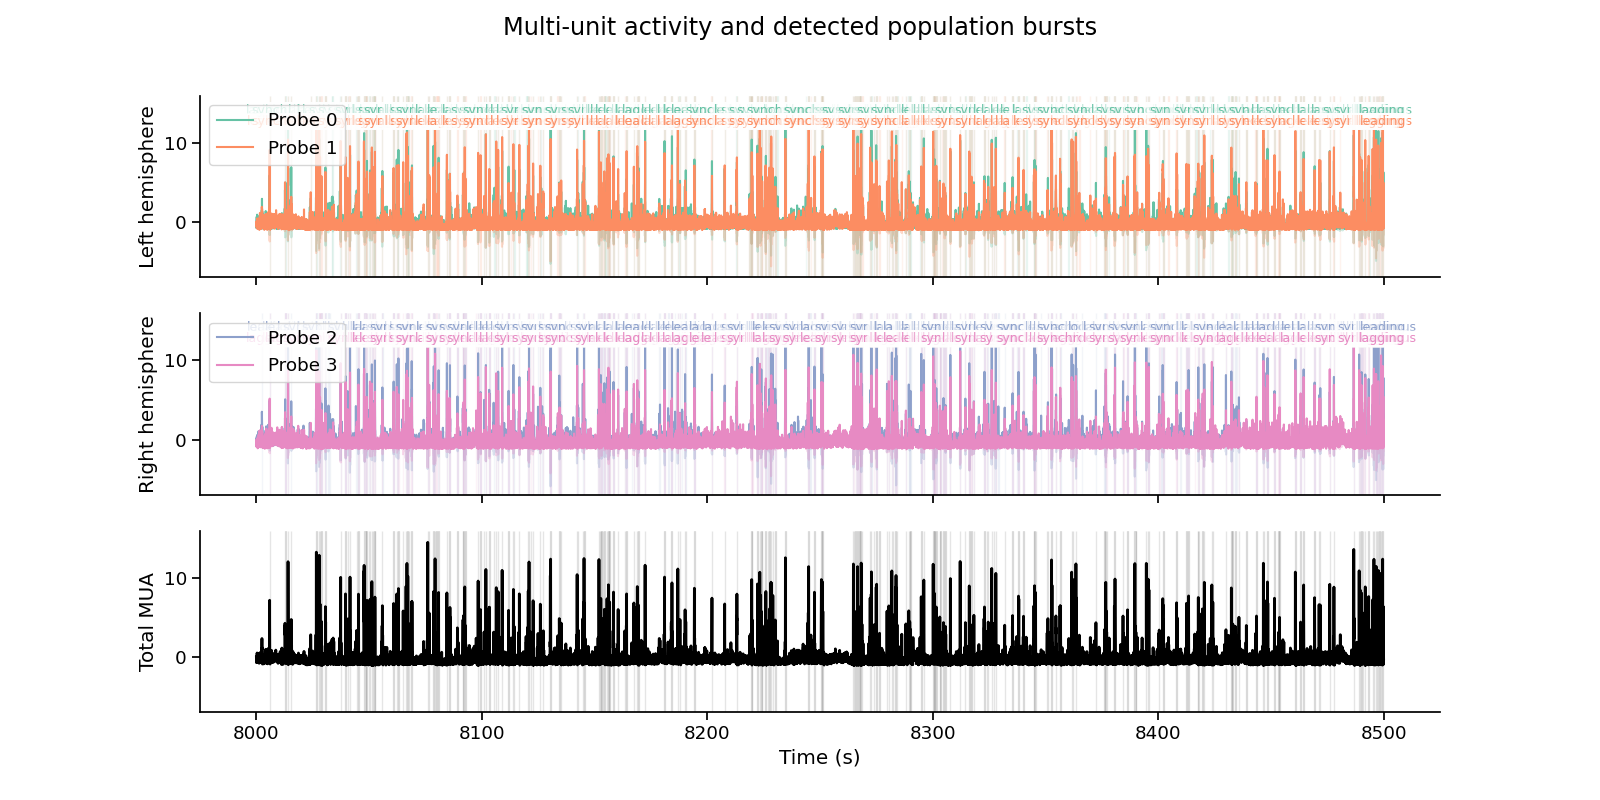

In [11]:
plot_bursts = True

# Optional: set these (in seconds). Use None for "full range".
start_time_s = 8000
end_time_s   = 8500

sos_theta = butter(4, [5, 10], btype="bandpass", fs=100, output="sos")

colors = sns.color_palette("Set2", len(PROBES))
sns.set_context("notebook", font_scale=1.2)

fig, axs = plt.subplots(3, 1, figsize=(16, 8), sharex=True, sharey=True)


for ax, hemisphere in zip(axs, ["L", "R"]):
    hemisphere_title = "Left" if hemisphere == "L" else "Right"
    probes_in_hemi = [p for p in PROBES if HEMISPHERE_DICT.get(p) == hemisphere]
    if not probes_in_hemi:
        ax.set_ylabel(f"{hemisphere_title} Hemisphere MUA (z)")
        continue

    for probe in probes_in_hemi:
        zmoothed_mua = data_dict[probe].get("zmoothed_mua")
        time_bins = data_dict[probe].get("time_bins")
        if zmoothed_mua is None or time_bins is None:
            continue

        # Ensure numpy arrays
        time_bins = np.asarray(time_bins)
        zmoothed_mua = np.asarray(zmoothed_mua)

        # Map requested time window (seconds) -> indices
        t0 = time_bins[0] if start_time_s is None else max(start_time_s, time_bins[0])
        t1 = time_bins[-1] if end_time_s   is None else min(end_time_s,   time_bins[-1])
        if t1 <= t0:
            continue  # or raise ValueError("end_time_s must be > start_time_s")

        i0 = np.searchsorted(time_bins, t0, side="left")
        i1 = np.searchsorted(time_bins, t1, side="right")  # slice end (exclusive)

        # Slice to window
        tb = time_bins[i0:i1]
        z  = zmoothed_mua[i0:i1]
        theta_mua = sosfiltfilt(sos_theta, zmoothed_mua)[i0:i1]


        c = colors[PROBES.index(probe)]
        ax.plot(tb, z, label=f"Probe {probe}", color=c)
        ax.plot(tb, theta_mua, color=c, alpha=0.3)

        if plot_bursts:
            burst_boundaries = data_dict[probe].get("burst_boundaries_merged", [])
            burst_subtypes   = data_dict[probe].get("burst_subtype", [])

            # Safety: if labels missing or length mismatch, fall back gracefully
            if len(burst_subtypes) != len(burst_boundaries):
                # You can raise instead if you prefer strictness:
                # raise ValueError(f"{probe}: burst_subtype length {len(burst_subtypes)} != burst_boundaries length {len(burst_boundaries)}")
                burst_subtypes = [""] * len(burst_boundaries)

            # Put labels near the top of the axis; small offset per probe to reduce collisions
            probe_rank = probes_in_hemi.index(probe) if probe in probes_in_hemi else 0
            y_text_ax = 0.92 - 0.06 * probe_rank  # axis fraction

            for (start_idx, end_idx), subtype in zip(burst_boundaries, burst_subtypes):
                # Convert burst indices -> times (assuming inclusive end_idx)
                b0 = time_bins[start_idx]
                b1 = time_bins[end_idx]

                # Skip if no overlap with view window
                if b1 < t0 or b0 > t1:
                    continue

                # Clip span to window
                span0 = max(b0, t0)
                span1 = min(b1, t1)

                # Shade burst
                ax.axvspan(span0, span1, color=c, alpha=0.1)

                # Label at midpoint of the *visible* span
                xm = 0.5 * (span0 + span1)
                if subtype:  # don't draw empty labels
                    ax.text(
                        xm, y_text_ax, subtype,
                        color=c,
                        fontsize=9,
                        ha="center", va="center",
                        transform=ax.get_xaxis_transform(),  # x in data, y in axes fraction
                        clip_on=True,
                        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.6),
                    )


      
    ax.legend()
    ax.set_ylabel(f"{hemisphere_title} hemisphere")    

axs[2].plot(tb, total_zmua[i0:i1], label="Total MUA", color="k", linewidth=2)
if plot_bursts:
    for start_idx, end_idx in total_burst_boundaries:
        b0 = time_bins[start_idx]
        b1 = time_bins[end_idx]
        if b1 < t0 or b0 > t1:
            continue
        span0 = max(b0, t0)
        span1 = min(b1, t1)
        axs[2].axvspan(span0, span1, color="k", alpha=0.1)
axs[2].set_ylabel("Total MUA")


fig.suptitle("Multi-unit activity and detected population bursts")
axs[-1].set_xlabel("Time (s)")
sns.despine()
plt.show()


## Loading in the behavior data

Tracking keys: ('timestamps', 'frameCount', 'position', 'orientation', 'errorPerMarker', 'substructnames', 'rotation_type', 'acquisition_system', 'description')
Loaded tracking data with 308232 timestamps and position shape (308232,) for x and (308232,) for y.


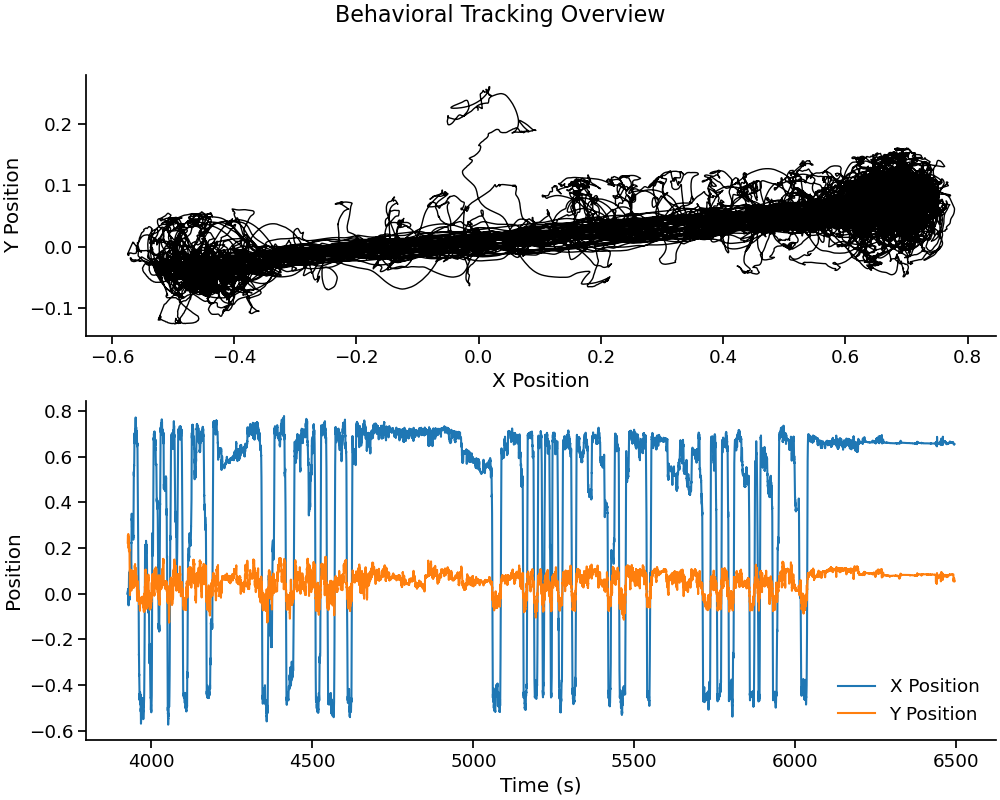

In [12]:
tracking_file = os.path.join(BASEPATH, f"{BASE_NAME}_imec0.tracking.behavior.mat")
tracking = loadmat(tracking_file, squeeze_me=True)['tracking']
print("Tracking keys:", tracking.dtype.names)

tracking_timestamps = tracking['timestamps'].item()
position = tracking['position'].item()
x, y = np.array(position['x'].item()), np.array(position['y'].item())
print(f'Loaded tracking data with {len(tracking_timestamps)} timestamps and position shape {x.shape} for x and {y.shape} for y.')

start_behavior_time = tracking_timestamps[0]
end_behavior_time = tracking_timestamps[-1]





fig, axs = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

# --- Top: XY trajectory ---
axs[0].plot(x, y, color="black", linewidth=1)
axs[0].set_xlabel("X Position")
axs[0].set_ylabel("Y Position")
axs[0].set_aspect("equal")  # preserves spatial geometry
sns.despine(ax=axs[0])

# --- Bottom: Position over time ---
axs[1].plot(tracking_timestamps, x, label="X Position", linewidth=1.5)
axs[1].plot(tracking_timestamps, y, label="Y Position", linewidth=1.5)
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Position")
axs[1].legend(frameon=False)
sns.despine(ax=axs[1])

fig.suptitle("Behavioral Tracking Overview", fontsize=16)
plt.show()


## Fitting the GPLVM

In [12]:
# building a matrix of all the spike counts from the specified hemisphere
use_hemi = 'R'

if use_hemi == 'R':
    use_probes = [p for p in HEMISPHERE_DICT.keys() if HEMISPHERE_DICT[p] == 'R']
else:
    use_probes = [p for p in HEMISPHERE_DICT.keys() if HEMISPHERE_DICT[p] == 'L']

for probe in use_probes:
    cellIDs = data_dict[probe]['cellIDs']
    spike_counts = data_dict[probe]['spike_count_matrix']
    valid_units = data_dict[probe]['valid_units']
    spike_counts_use_probe = spike_counts[valid_units, :]
    cellIDs_use_probe = cellIDs[valid_units]
    print(f"Probe {probe}: using {spike_counts_use_probe.shape[0]} units for GPLVM after filtering.")
    if probe == use_probes[0]:
        spike_counts_use = spike_counts_use_probe
        cellIDs_use = cellIDs_use_probe
    else:
        spike_counts_use = np.vstack((spike_counts_use, spike_counts_use_probe))
        cellIDs_use = np.concatenate((cellIDs_use, cellIDs_use_probe))

        

# building masks for the pre-behavior, behavior, and post-behavior time bins based on the tracking timestamps
time_bins = data_dict[use_probes[0]]['time_bins']
pre_behavior_mask = time_bins < start_behavior_time
behavior_mask = (time_bins >= start_behavior_time) & (time_bins <= end_behavior_time)
post_behavior_mask = time_bins > end_behavior_time

# sanity check: these masks should be mutually exclusive and cover all time bins
assert np.all(~(pre_behavior_mask & behavior_mask))
assert np.all(~(pre_behavior_mask & post_behavior_mask))
assert np.all(~(behavior_mask & post_behavior_mask))
assert np.all(pre_behavior_mask | behavior_mask | post_behavior_mask)

# defining the spike counts matrix that will be used for fitting the GPLVM
spike_counts_fit = spike_counts_use[:, pre_behavior_mask]
print(f"After filtering to behavior time window, spike counts shape is {spike_counts_fit.shape} (units x time bins).")


model = pmg.PoissonGPLVMJump1D(spike_counts_fit.shape[0], n_latent_bin = N_LATENT_BINS, movement_variance=MOVEMENT_VARIANCE, tuning_lengthscale=TUNING_LENGTHSCALE)
em_res = model.fit_em(spike_counts_fit.T, n_iter=30)

Probe 2: using 232 units for GPLVM after filtering.
Probe 3: using 181 units for GPLVM after filtering.
After filtering to behavior time window, spike counts shape is (413, 392636) (units x time bins).


c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\jax\_src\abstract_arrays.py:68: RuntimeWarning:

overflow encountered in cast

c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\jax\_src\interpreters\xla.py:158: RuntimeWarning:

overflow encountered in cast

EM:   0%|          | 0/30 [00:00<?, ?it/s]c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\jax\_src\abstract_arrays.py:68: RuntimeWarning:

overflow encountered in cast

c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\jax\_src\lax\lax.py:2476: RuntimeWarning:

overflow encountered in cast

EM: 100%|██████████| 30/30 [3:52:48<00:00, 465.63s/it]  


## Plotting some fitting metrics

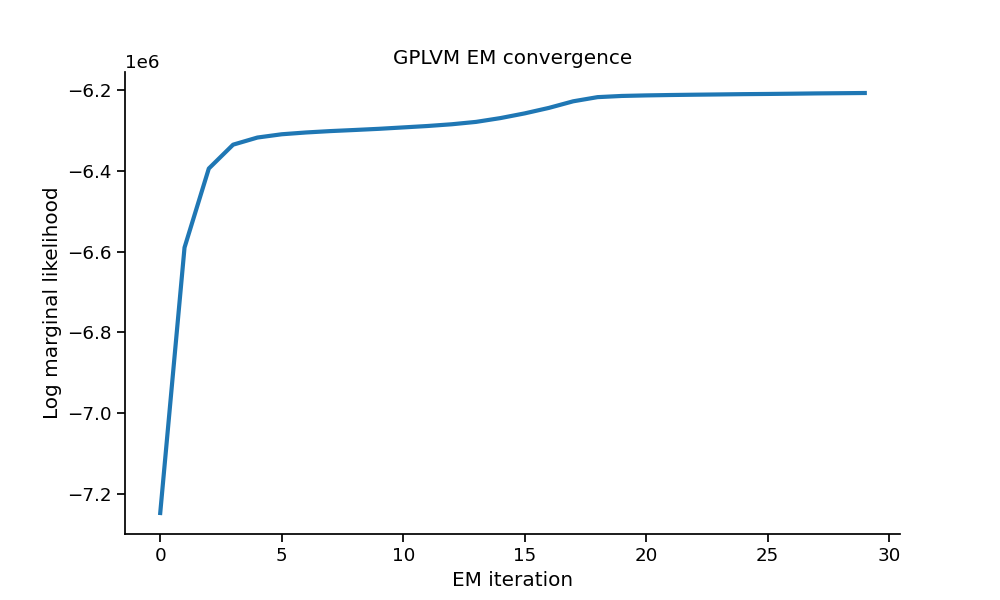

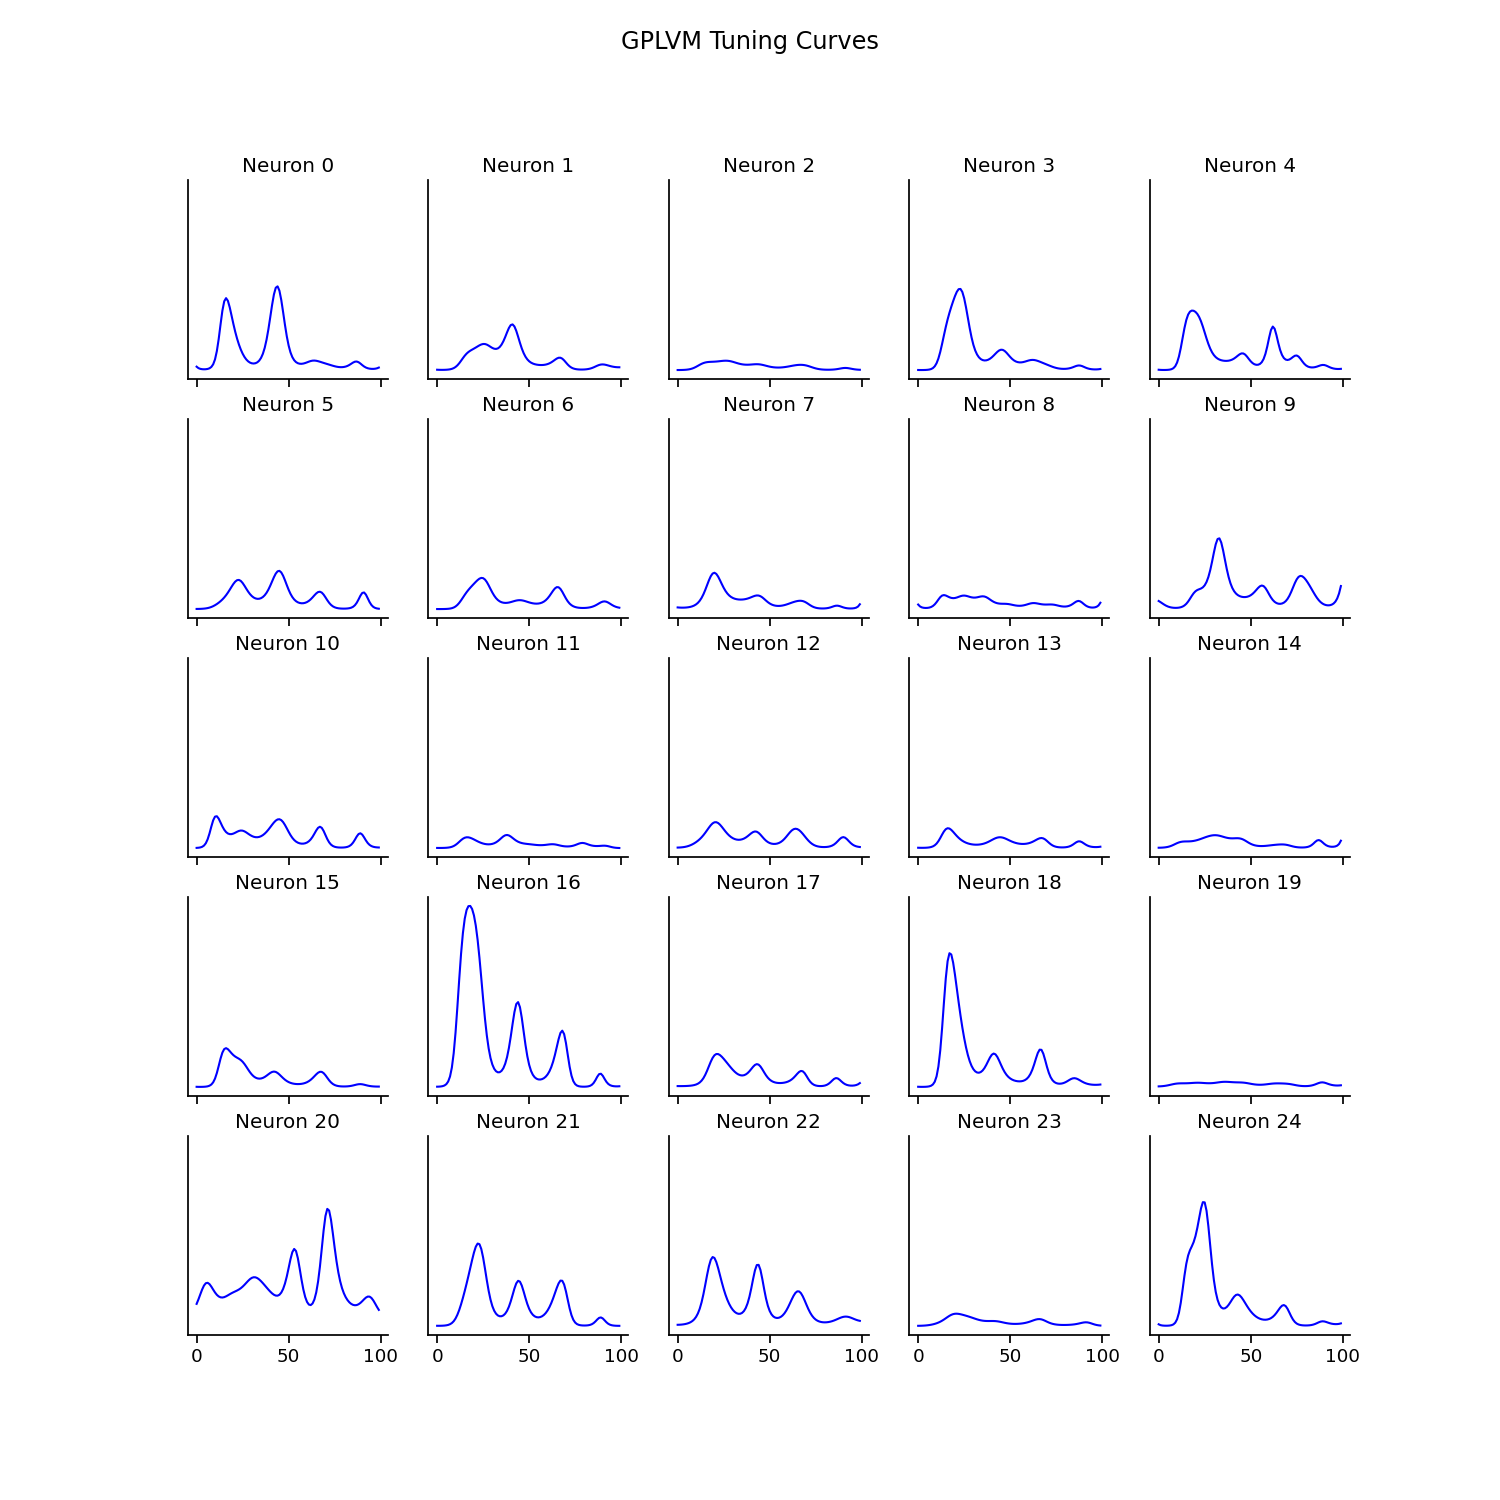

In [14]:
# plotting the EM convergence
plt.figure(figsize=(10, 6))
plt.plot(em_res['log_marginal_l'], linewidth = 3)
plt.xlabel("EM iteration")
plt.ylabel("Log marginal likelihood")
plt.title("GPLVM EM convergence")
sns.despine()
plt.show()

# plotting the tuning curves for the first 25 neurons
tuning_curves = model.tuning
rows = 5
fig, axs = plt.subplots(rows, rows, figsize=(15,15), sharex=True, sharey=True)
for neuron in range(rows * rows):
    r = neuron // rows
    c = neuron % rows
    axs[r, c].plot(tuning_curves[:, neuron], color="blue")
    axs[r, c].set_title(f"Neuron {neuron}")
    axs[r, c].set_yticks([])
    sns.despine(ax=axs[r, c])
plt.suptitle("GPLVM Tuning Curves")
plt.show()



In [15]:
decode_res = model.decode_latent(spike_counts_use.T)

c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\jax\_src\abstract_arrays.py:68: RuntimeWarning:

overflow encountered in cast

c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\jax\_src\lax\lax.py:2476: RuntimeWarning:

overflow encountered in cast



In [16]:
import pickle
from pathlib import Path
from datetime import datetime

def save_model(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)


save_model(model, os.path.join(BASEPATH, f"{BASE_NAME}_gplvm_model_pre_sleep_fit_tls-{model.tuning_lengthscale}_mv-{model.movement_variance}_nlb-{model.n_latent_bin}_date-{datetime.now().strftime('%Y%m%d')}.pkl"))
np.savez(os.path.join(BASEPATH, f"{BASE_NAME}_gplvm_decode_results_pre_sleep_fit_date-{datetime.now().strftime('%Y%m%d')}.npz"), **decode_res)
np.savez(os.path.join(BASEPATH, f"{BASE_NAME}_gplvm_em_results_pre_sleep_fit_date-{datetime.now().strftime('%Y%m%d')}.npz"), **em_res)

In [ ]:
# LOADING A MODEL

def load_model(path):
    with open(path, "rb") as f:
        model = pickle.load(f)
    return model

model = load_model("models/poisson_gplvm_jump1d.pkl")

# IMPORTANT: call fit_em again only if you want to refit.
# To decode using the loaded parameters:
# (you likely need to rebuild JIT callables before m_step, but decode functions should work if they don't rely on adam_runner)


In [17]:
# print the model info and the decoding results
print("\nGPLVM Model Info:")
print(f"  Number of latent bins: {model.n_latent_bin}")
print(f"  Movement variance: {model.movement_variance}")
print(f"  Tuning lengthscale: {model.tuning_lengthscale}")
print("\nDecoding Results:")
print(decode_res.keys())


GPLVM Model Info:
  Number of latent bins: 25
  Movement variance: 0.5
  Tuning lengthscale: 7

Decoding Results:
dict_keys(['log_posterior_all', 'log_marginal_final', 'posterior_all', 'posterior_latent_marg', 'posterior_dynamics_marg', 'log_one_step_predictive_marginals_all', 'log_likelihood_all', 'log_joint_dynamics', 'log_joint_full', 'log_joint_latent', 'log_transition_dynamics', 'log_transition_full', 'log_transition_latent', 'p_joint_dynamics', 'p_joint_full', 'p_joint_latent', 'p_transition_dynamics', 'p_transition_full', 'p_transition_latent'])


In [19]:
print(decode_res.keys())
posterior = decode_res['posterior_latent_marg']  # shape: (n_time_bins, n_latent_bins)
print(posterior.shape)

dict_keys(['log_posterior_all', 'log_marginal_final', 'posterior_all', 'posterior_latent_marg', 'posterior_dynamics_marg', 'log_one_step_predictive_marginals_all', 'log_likelihood_all', 'log_joint_dynamics', 'log_joint_full', 'log_joint_latent', 'log_transition_dynamics', 'log_transition_full', 'log_transition_latent', 'p_joint_dynamics', 'p_joint_full', 'p_joint_latent', 'p_transition_dynamics', 'p_transition_full', 'p_transition_latent'])
(1052094, 100)


In [17]:
# discretize the position 
pos = x
pos_bins = np.linspace(pos.min(), pos.max(), N_LATENT_BINS + 1)
pos_bin_centers = (pos_bins[:-1] + pos_bins[1:]) / 2
pos_bin_indices = np.digitize(pos, pos_bins) - 1  # bin indices for each time point, 0-indexed
pos_bin_indices = np.clip(pos_bin_indices, 0, N_LATENT_BINS - 1)  # ensure indices are within valid range
pos_bin_indices = N_LATENT_BINS - 1 - pos_bin_indices # reverse order to match the latent bins

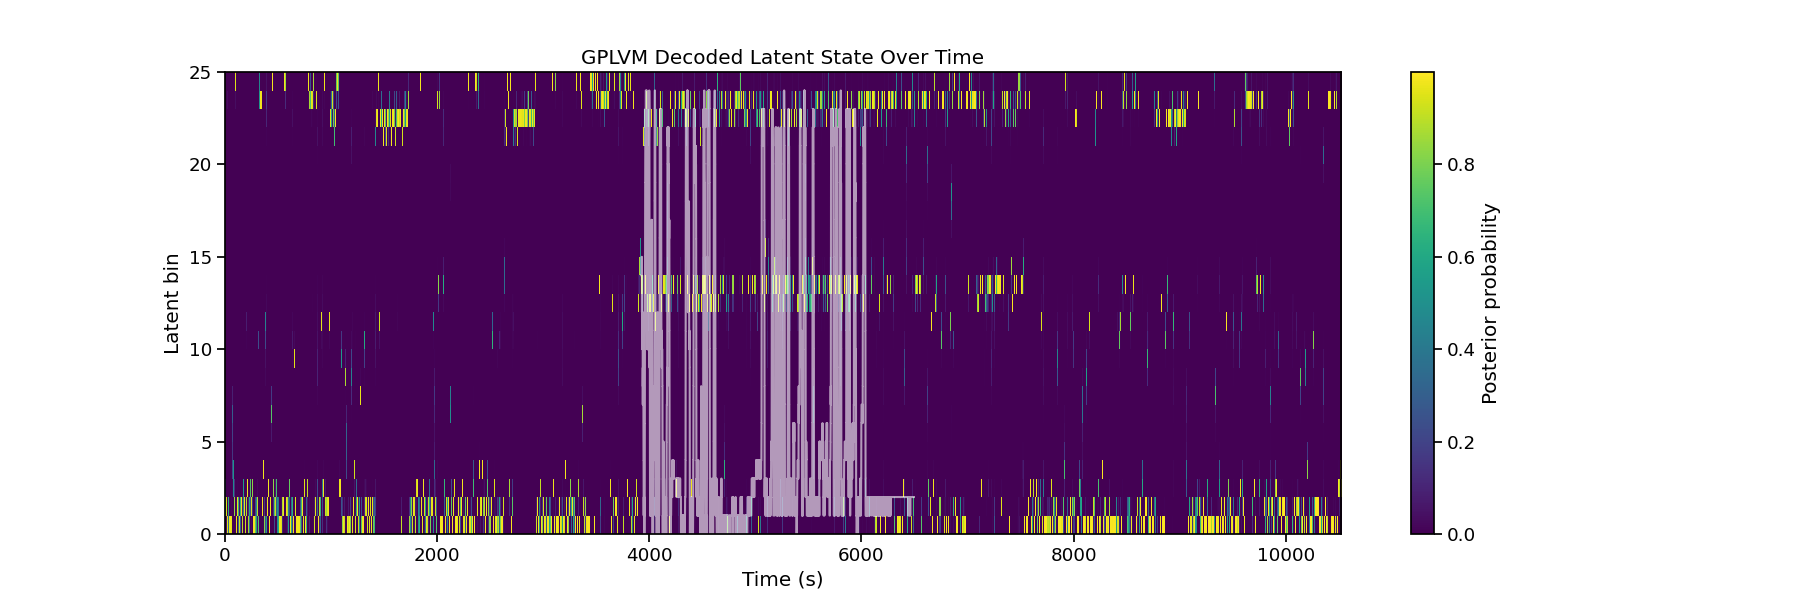

In [20]:
plt.figure(figsize=(18, 6))
plt.imshow(posterior.T, aspect='auto', origin='lower', cmap='viridis', extent=[time_bins[0], time_bins[-1], 0, N_LATENT_BINS])
plt.plot(tracking_timestamps, pos_bin_indices, label="X Position", color="white", linewidth=1.5, alpha = 0.6)
plt.colorbar(label='Posterior probability')
plt.xlabel('Time (s)')
plt.ylabel('Latent bin')
plt.title('GPLVM Decoded Latent State Over Time')
plt.show()

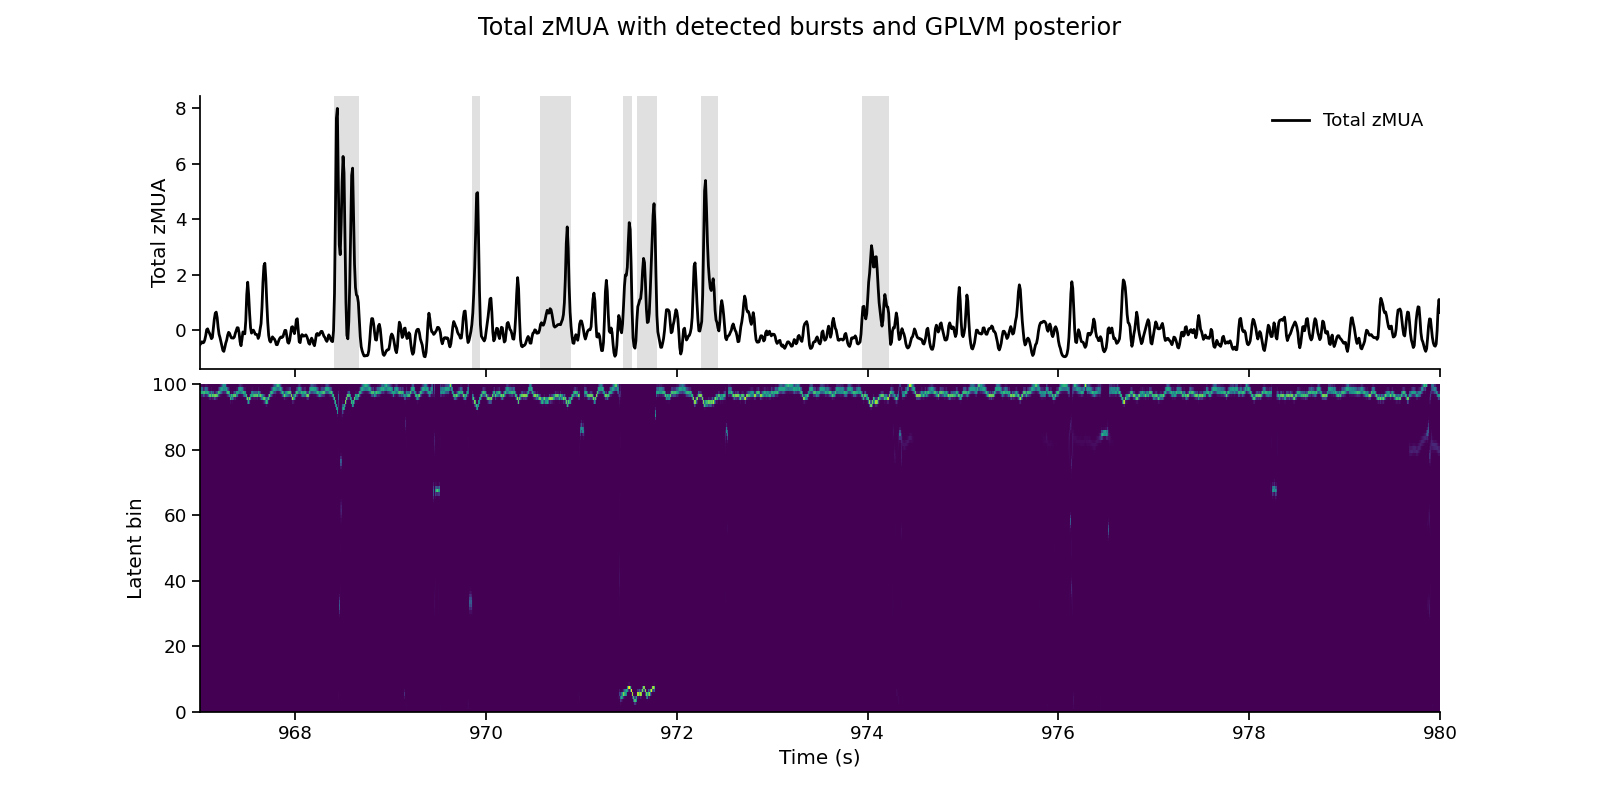

In [20]:
# --- time window -> indices (compute once) ---
time_bins = np.asarray(time_bins)  # use the same time_bins that total_zmua/posterior correspond to

start_time_s = 967
end_time_s = 980


t0 = time_bins[0] if start_time_s is None else max(start_time_s, time_bins[0])
t1 = time_bins[-1] if end_time_s  is None else min(end_time_s,  time_bins[-1])
if t1 <= t0:
    raise ValueError("end_time_s must be > start_time_s")

i0 = np.searchsorted(time_bins, t0, side="left")
i1 = np.searchsorted(time_bins, t1, side="right")  # exclusive

tb = time_bins[i0:i1]

# --- slice data ---
total_seg = np.asarray(total_zmua)[i0:i1]
post_seg  = np.asarray(posterior)[i0:i1, :]   # (time, latent)

# --- figure ---
fig, (ax_top, ax_hm) = plt.subplots(
    2, 1,
    figsize=(16, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1.2], "hspace": 0.05}
)

# ======================
# Top: total MUA + bursts
# ======================
ax_top.plot(tb, total_seg, color="k", linewidth=2, label="Total zMUA")

if plot_bursts:
    for start_idx, end_idx in total_burst_boundaries:
        b0 = time_bins[start_idx]
        b1 = time_bins[end_idx]  # assuming inclusive end_idx in your boundaries

        # overlap with window?
        if b1 < t0 or b0 > t1:
            continue

        # clip to window
        span0 = max(b0, t0)
        span1 = min(b1, t1)
        ax_top.axvspan(span0, span1, color="k", alpha=0.12, linewidth=0)

ax_top.set_ylabel("Total zMUA")
ax_top.legend(frameon=False, loc="upper right")
sns.despine(ax=ax_top)

# ======================
# Bottom: posterior heatmap
# ======================
# If latent bins are 0..N_LATENT_BINS-1, make y-extent match that.
# Using [0, post_seg.shape[1]] makes bin edges line up nicely.
im = ax_hm.imshow(
    post_seg.T,
    aspect="auto",
    origin="lower",
    extent=[t0, t1, 0, post_seg.shape[1]],
    interpolation="nearest"
)

ax_hm.set_ylabel("Latent bin")
ax_hm.set_xlabel("Time (s)")
sns.despine(ax=ax_hm, left=False, bottom=False)


fig.suptitle("Total zMUA with detected bursts and GPLVM posterior", y=0.98)
plt.show()

In [ ]:
# getting the distribution of posterior probabilites of the population burst subtypes


burst_subtypes = ['synchronous', 'leading', 'lagging', 'local']
sleep_states = ['NREMstate']
activation_distributions = np.zeros((len(burst_subtypes) + 1, N_LATENT_BINS))  # (subtypes, latent_bins)

use_probe = 2
burst_boundaries = data_dict[use_probe].get("burst_boundaries_merged", [])
burst_subtypes_probe = data_dict[use_probe].get("burst_subtype", [])
sleep_states_probe = data_dict[use_probe].get("SleepState", None)
time_bins = data_dict[use_probe]["time_bins"]

for (start_idx, end_idx), subtype in zip(burst_boundaries, burst_subtypes_probe):
    if subtype not in burst_subtypes:
        print(f"Warning: Unrecognized burst subtype '{subtype}'")
        continue

    # skip if the start_idx is not after the end of the behavior time window, since the GPLVM was only fit on pre-behavior data
    #if time_bins[end_idx] > start_behavior_time:
        #continue

    # check to ensure the burst is in the specified sleep states if sleep state info is available
    filter_sleep_states = True
    if filter_sleep_states:
        if sleep_states_probe:
            b0_t = time_bins[start_idx]
            b1_t = time_bins[end_idx]

            in_desired_state = False
            for state_name, state_intervals in sleep_states_probe.items():
                if state_name not in sleep_states:
                    continue

                # Ensure Nx2 array
                intervals = np.asarray(state_intervals)
                if intervals.ndim == 1 and intervals.size == 2:
                    intervals = intervals[None, :]

                for s_t, e_t in intervals:
                    # overlap in time (robust)
                    if (b0_t < e_t) and (s_t < b1_t):
                        in_desired_state = True
                        break
                if in_desired_state:
                    break

            if not in_desired_state:
                continue
        else:
            print(f"Warning: No sleep state information found for probe {use_probe}. Skipping sleep state filtering.")


    # Convert burst indices -> times (assuming inclusive end_idx)
    b0 = time_bins[start_idx]
    b1 = time_bins[end_idx]

    # Find corresponding indices in the posterior time bins
    i0 = np.searchsorted(time_bins, b0, side="left")
    i1 = np.searchsorted(time_bins, b1, side="right")  # exclusive

    # Average posterior over this burst period
    if i1 > i0:  # ensure there's at least some time points in the burst
        avg_posterior = posterior[i0:i1, :].mean(axis=0)  # (latent_bins,)
        subtype_idx = burst_subtypes.index(subtype)
        activation_distributions[subtype_idx, :] += avg_posterior

# Normalize distributions for each subtype
activation_distributions /= activation_distributions.sum(axis=1, keepdims=True)


# getting the local events on the other probe
other_probe = 2 if use_probe == 3 else 3
other_burst_boundaries = data_dict[other_probe].get("burst_boundaries_merged", [])
other_burst_subtypes = data_dict[other_probe].get("burst_subtype", [])
local_activation_distribution = np.zeros(N_LATENT_BINS)
for (start_idx, end_idx), subtype in zip(other_burst_boundaries, other_burst_subtypes):
    if subtype != "local":
        continue

    b0 = time_bins[start_idx]
    b1 = time_bins[end_idx]

    i0 = np.searchsorted(time_bins, b0, side="left")
    i1 = np.searchsorted(time_bins, b1, side="right")  # exclusive

    if i1 > i0:
        avg_posterior = posterior[i0:i1, :].mean(axis=0)
        local_activation_distribution += avg_posterior

local_activation_distribution /= local_activation_distribution.sum()

burst_subtypes.append("local other")
activation_distributions[-1, :] = local_activation_distribution


# smooth the distributions for better visualization
activation_distributions_smooth = gaussian_filter1d(activation_distributions, sigma=1, axis=1)


C:\Users\SB13FLPC020\AppData\Local\Temp\ipykernel_16260\1276645856.py:69: RuntimeWarning:

invalid value encountered in divide



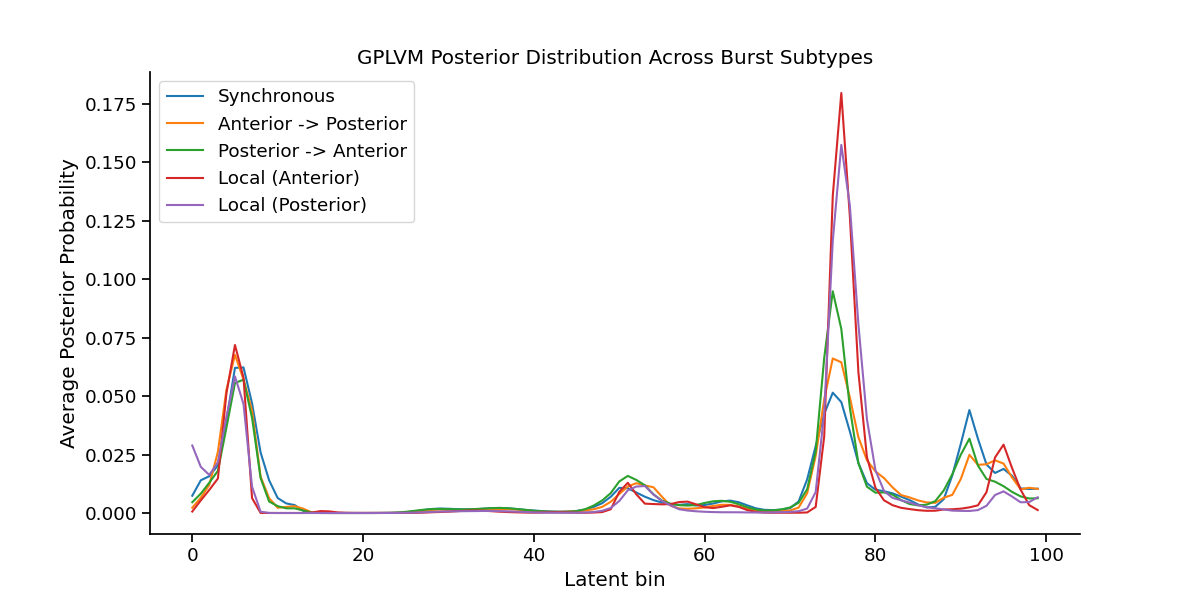

In [30]:

labels = {
    'synchronous': 'Synchronous',
    'leading': 'Anterior -> Posterior',
    'lagging': 'Posterior -> Anterior',
    'local': 'Local (Anterior)',
    'local other': 'Local (Posterior)'
}

# Plotting the activation distributions
plt.figure(figsize=(12, 6))
for i, subtype in enumerate(burst_subtypes):
    plt.plot(np.linspace(0, N_LATENT_BINS - 1, N_LATENT_BINS), activation_distributions[i, :], label=labels[subtype])
plt.xlabel("Latent bin")
plt.ylabel("Average Posterior Probability")
plt.title("GPLVM Posterior Distribution Across Burst Subtypes")
plt.legend()
sns.despine()
plt.show()


Unique (probe, shank) groups in the data: 8


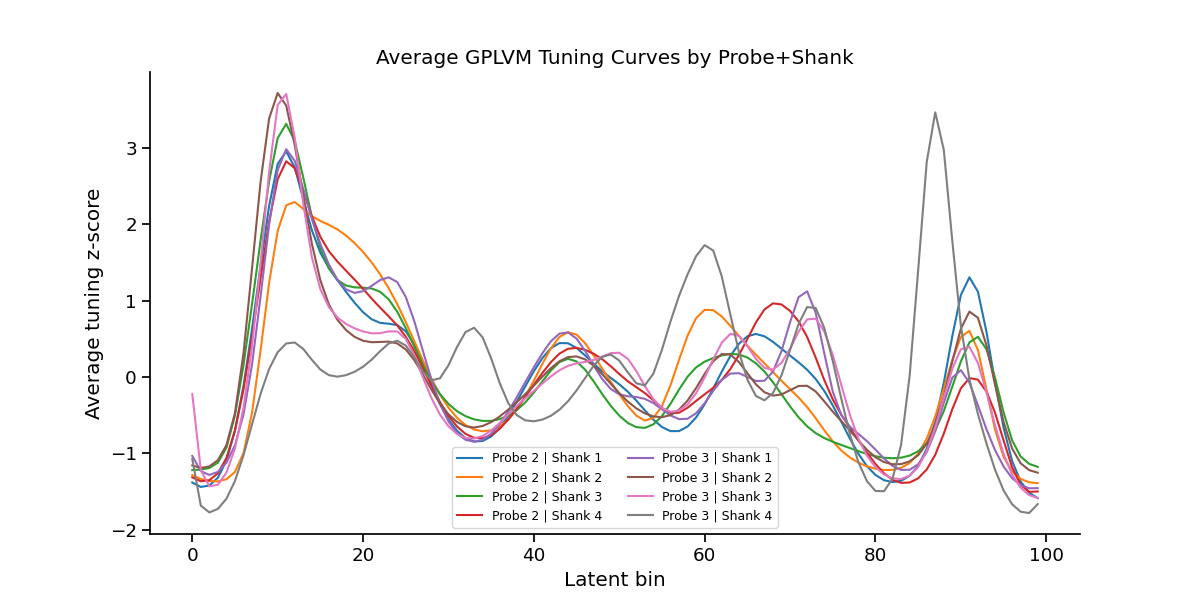

In [23]:
sleep_states = ['NREMstate']

# Build aligned labels (same order as the units in spike_counts_fit / model.tuning)
probe_labels = []
shank_labels = []
use_probes = [p for p in PROBES if HEMISPHERE_DICT.get(p) == use_hemi]
for probe in use_probes:
    shankIDs_probe = np.asarray(data_dict[probe]['shankID'])
    valid_units = np.asarray(data_dict[probe]['valid_units'])

    shank_use = shankIDs_probe[valid_units]
    probe_use = np.full(shank_use.shape[0], probe)  # works for strings or ints

    shank_labels.append(shank_use)
    probe_labels.append(probe_use)

probe_labels = np.concatenate(probe_labels)     # (n_units,)
shank_labels = np.concatenate(shank_labels)     # (n_units,)

tuning = np.asarray(model.tuning)               # (n_latent_bins, n_units)

assert shank_labels.shape[0] == spike_counts_fit.shape[0] == tuning.shape[1], \
    f"Mismatch: shank_labels={shank_labels.shape[0]}, spike_counts_fit={spike_counts_fit.shape[0]}, tuning={tuning.shape[1]}"

# ---- Compute avg tuning per (probe, shank) without np.unique(axis=0) ----
groups = sorted(set(zip(probe_labels.tolist(), shank_labels.tolist())))
print(f"Unique (probe, shank) groups in the data: {len(groups)}")


avg_tuning = {}
for probe, shank in groups:
    mask = (probe_labels == probe) & (shank_labels == shank)
    avg_tuning[(probe, int(shank))] = zscore(tuning[:, mask].mean(axis=1))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 6))
for (probe, shank), curve in avg_tuning.items():
    ax.plot(curve, label=f"Probe {probe} | Shank {shank}")

ax.set_title("Average GPLVM Tuning Curves by Probe+Shank")
ax.set_xlabel("Latent bin")
ax.set_ylabel("Average tuning z-score")
ax.legend(ncol=2, fontsize=9)
sns.despine()
plt.show()
